# STA 554 Final Project
Jillian Greene

This project will assess our ability to use spark for data streaming, machine learning, and more.

In [27]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import SQLTransformer, Binarizer, StringIndexer, OneHotEncoder, VectorAssembler, PCA
from pyspark.ml.regression import LinearRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

In [28]:
# Read in power_ml_data with pandas
power_ml_pd = pd.read_csv("power_ml_data.csv")

power_ml_pd.head()

,Temperature,Humidity,Wind_Speed,General_Diffuse_Flows,Diffuse_Flows,Power_Zone_1,Power_Zone_2,Power_Zone_3,Month,Hour
0,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,1,0
1,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,1,0
2,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,1,0
3,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,1,0
4,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,1,0


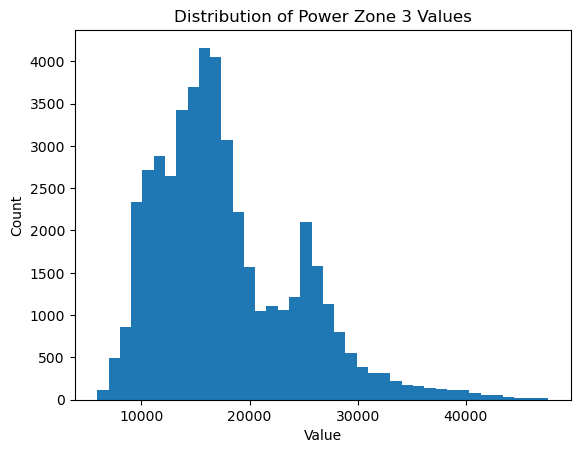

In [31]:
# Histogram of Power_Zone_3 to get familiar with the data we're modeling
power_ml_pd['Power_Zone_3'].plot(kind='hist', bins=40, title='Distribution of Power Zone 3 Values')
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()

Since we'll be modeling `Power_Zone_3`, I plotted the distribution of the values to get familiar with what to expect. It has a bimodal distribution with values roughly from 10,000 - 50,000. This will be helpful to know when interpreting the RMSE.

In [3]:
# Initialize Spark
spark = SparkSession.builder.getOrCreate()

# Convert to spark dataframe
power_ml_sp = spark.createDataFrame(power_ml_pd)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/22 10:56:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


We want to fit an elastic net model using CV (no training/test split, just using CV on the data we’ve read in). Imagine we know that the Power_Zone_3 reading
is going to go offline in the future and we need to be able to predict that value appropriately.

### Transformations

In [4]:
# Recast Hour
cast_hour = SQLTransformer(statement="""
    SELECT *, CAST(Hour AS DOUBLE) as Hour_double FROM __THIS__
    """)

# Binarize Hour for night and day
binarizer = Binarizer(inputCol="Hour_double", outputCol="Hour_binary", threshold=6.5)

# One-hot encode Month (a function for this! I've always done it messily myself)
month_indexer = StringIndexer(inputCol="Month", outputCol="Month_index", handleInvalid="keep")

month_encoder = OneHotEncoder(inputCol="Month_index", outputCol="Month_ohe")

# PCA on climate and diffuse flows cols
pca_features = ["Temperature", "Humidity", "Wind_Speed", "General_Diffuse_Flows", "Diffuse_Flows"]

pca_assembler = VectorAssembler(inputCols=pca_features, outputCol="pca_input")

pca = PCA(k=2, inputCol="pca_input", outputCol="pca_features")

# Recode Power_Zone_3 as the label
rename_label = SQLTransformer(statement="""
    SELECT *, Power_Zone_3 as label FROM __THIS__
    """)

# Assemble features
final_features = VectorAssembler(
    inputCols=["pca_features", "Hour_binary", "Power_Zone_1", "Power_Zone_2", "Month_ohe"],
    outputCol="features")

### Set up model pipeline

In [12]:
# Initialize model
lr = LinearRegression(featuresCol="features", labelCol="label")

# Set up parameter grid for tuning with req. combinations
paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98, 0.99, 1]) \
    .addGrid(lr.elasticNetParam, [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98, 0.99, 1]) \
    .build()

# Evaluator for RMSE
evaluator = RegressionEvaluator(labelCol="label",
    predictionCol="prediction",
    metricName="rmse")

# Pipeline
pipeline = Pipeline(stages=[cast_hour, binarizer, month_indexer, month_encoder, pca_assembler,
                            pca, rename_label, final_features])

### Cross Validation

In [6]:
cv = CrossValidator(estimator=Pipeline(stages=pipeline.getStages() + [lr]),
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5)

### Fit Model

This will take a long time, since the parameter grid is so large

In [7]:
# Test this to hide long warnings list
spark.sparkContext.setLogLevel("ERROR")

cv_model = cv.fit(power_ml_sp)

26/04/22 11:01:01 ERROR LBFGS: Failure! Resetting history: breeze.optimize.FirstOrderException: Line search zoom failed
26/04/22 11:01:07 ERROR LBFGS: Failure! Resetting history: breeze.optimize.FirstOrderException: Line search zoom failed


In [8]:
# Extract best model and stats
best_model = cv_model.bestModel.stages[-1]

print("Best regParam:", best_model._java_obj.getRegParam())
print("Best elasticNetParam:", best_model._java_obj.getElasticNetParam())
print("CV RMSE:", min(cv_model.avgMetrics))

Best regParam: 0.99
Best elasticNetParam: 0.9
CV RMSE: 2147.940726578216


### Apply model as transformer for training RMSE

In [20]:
predictions = cv_model.transform(power_ml_sp)

train_rmse = evaluator.evaluate(predictions)
print("Training RMSE:", train_rmse)

Training RMSE: 2147.101028123537


In [21]:
# Create and print residuals column
results_df = predictions.withColumn("residual",
    F.col("label") - F.col("prediction")).select("label", "prediction", "residual")

results_df.show(20)

+-----------+------------------+------------------+
|      label|        prediction|          residual|
+-----------+------------------+------------------+
|20240.96386| 20873.01583593524|-632.0519759352392|
|20131.08434|18652.204782341934| 1478.879557658067|
|19668.43373|18196.957422624248| 1471.476307375753|
|18899.27711|17583.258044362126|1316.0190656378727|
|18442.40964|16990.213956069238| 1452.195683930764|
|18130.12048|16510.883068044037|1619.2374119559645|
|17945.06024|16086.706832510466|1858.3534074895324|
|17459.27711| 15716.36233009028| 1742.914779909719|
|17025.54217|15264.981724187957|1760.5604458120433|
|16794.21687|14932.465215616376|1861.7516543836246|
|16638.07229|14646.821029706902|1991.2512602930983|
|16395.18072|14409.476596604716|1985.7041233952841|
|16117.59036|14077.484113476017| 2040.106246523983|
| 15822.6506|13619.764362923164|2202.8862370768366|
|15672.28916|13445.406534205773|2226.8826257942274|
|15597.10843|13297.515041849681| 2299.593388150319|
|15510.36145

Based on the overall RMSE and the residuals printed above, the model seems to underpredict the `Power_Level_3` more often than overpredicting it

# Data streaming

In [22]:
# Set up schema
schema = power_ml_sp.schema

# Read the streaming data
stream_df = spark.readStream \
    .option("header", True) \
    .schema(schema) \
    .csv("powerStreaming")

In [23]:
# Apply the trained model
pred_stream = cv_model.transform(stream_df)

# Add residuals
pred_stream = pred_stream.withColumn("residual",
    F.col("label") - F.col("prediction")).select("label", "prediction", "residual")

# Transform the streamed data to rename label
stream_with_label = stream_df.withColumnRenamed("Power_Zone_3", "label")

# Join streams
joined_stream = pred_stream.join(stream_with_label, on="label")

In [ ]:
# Create query to write to console
query = joined_stream.writeStream \
    .outputMode("append") \
    .format("console") \
    .start()

In [ ]:
# Start loop from .py file - writes every 10 seconds
!python DataGeneration.py

In [26]:
# When done with above
query.stop()

26/04/22 11:38:46 ERROR TorrentBroadcast: Store broadcast broadcast_10543 fail, remove all pieces of the broadcast
